In [3]:
using Revise
using LinearAlgebra
using PyPlot
using TensorCrossInterpolation
using QuanticsTCI
using QuanticsGrids
using ITensors
using NDTensors
using ITensors
using ITensorMPS
using TCIITensorConversion
using PyCall
using Plots

# Get raw Python sys module without converting to Julia types
sys = pyimport("sys")
# Call Python's append method directly
sys["path"].append("C:/Users/tiagu/OneDrive/Ambiente de Trabalho")
gt = pyimport("generate_twisted")

#Performs QTCI on function f which is supposed to be a matrix of size 2^Nx2^N
function quanticsMPSMAT(f,maxbonddim, N, qtol)
    qgrid = QuanticsGrids.DiscretizedGrid{2}(Int(log2(N)), (1, 1), (N, N); includeendpoint=true,unfoldingscheme=:interleaved)
    ci, ranks, errors = quanticscrossinterpolate(Float64, f, qgrid; tolerance=qtol,maxbonddim=maxbonddim)
    println(ranks)
    citt = TensorCrossInterpolation.TensorTrain(ci.tci)
    
    mps_tt_2N = ITensors.MPS(citt)
    return mps_tt_2N
end

#Converts Quantics 2D MPS into MPO
function MPS_to_MPO_Q(mps_2N,N)
    #Contract MPS pairwise
    mps_N = MPS(N)
    for n in 1:N
        A = mps_2N[2n-1]
        B = mps_2N[2n]
        common_link = commonind(A, B)
        if common_link != nothing
            mps_N[n] = A * B
        end
    end
    
    l = linkinds(mps_N)
    
    newsiteinds = Vector{Index{Int64}}(undef, 2N)
    for n in 1:N
        tensor = mps_N[n]          
        # Replace site indices
        c = 0
        new_index = undef
        for site_ind in inds(tensor)
            if (!hastags(site_ind, "link")) && c == 0
                c += 1
                new_index = Index(2, "Site, n=$n")
                tensor = replaceind(tensor, site_ind, new_index)
                newsiteinds[2n - 1] = new_index
            elseif !hastags(site_ind, "link") && c == 1
                tensor = replaceind(tensor, site_ind, prime(new_index))
                newsiteinds[2n] = prime(new_index)
            end
        end
        
        #if n == 1
        #    tensor = replaceind(tensor, l[2], new_links[1])
        #elseif n == N
        #    tensor = replaceind(tensor, l[2(n-1)], new_links[n-1])
        #else
        #    tensor = replaceind(tensor, l[2(n-1)], new_links[n-1])
        #    tensor = replaceind(tensor, l[2n], new_links[n])
        #end
    
        mps_N[n] = tensor
    end

    # Replace link indices

    #Reshape to MPO
    H =  Vector{ITensor}(undef, N)

    for n in 1:N
        if n == 1
            H[n] = mps_N[n]
        elseif n == N
            H[n] = mps_N[n]
        else
            H[n] = mps_N[n]
        end
    end
    mpo = MPO(H)
    sites = [siteinds(mpo)[n][1] for n in 1:N]
    return mpo, sites
end

#Computes |x> from the "site number" n running from 1 to 2^N
function MPS_from_number(sites, n::Int)
    N = length(sites)
    number = n - 1
    # Generate N-bit binary string with leading zeros (MSB-first)
    binary_str = string(number, base=2, pad=N)
    # Reverse only if Quantics grid expects LSB-first (uncomment if needed)
    # binary_str = reverse(binary_str)
    init_states = [bit == '1' ? "1" : "0" for bit in binary_str]
    
    new_sites = siteinds("Qubit", N)
    psi = MPS(new_sites, init_states)
    
    for i in 1:N
        psi[i] = replaceind(psi[i], new_sites[i], sites[i])
    end
    
    return psi
end

MPS_from_number (generic function with 1 method)

In [9]:
# Generate the geometry
n = 2^5
#First 2 is from the two layers
#Second 2 is from the sublattice
rs = gt.generate_twisted_geometry("stacked_small_angle.txt", n, 0.01,lattice="honeycomb")
N = length(rs[:,1])

4096

In [12]:
# Define hopping functions

L = 10
Lperp = 5
J1 = 1
Jperp = 1

function t(r1,r2)
    if abs(r1[3] - r2[3]) < 1e-4
        res = J1 * exp(-norm(r1-r2)/L)
    else
        res = Jperp * exp(-norm(r1-r2)/Lperp)
    end
    return res
end


function tij(i,j)
    return t(rs[Int(i),:], rs[Int(j),:])
end

tij (generic function with 1 method)

In [13]:
# Perform quantics on the matrix
mps_2tt = quanticsMPSMAT(tij,15,N,1e-6)
mpo, sites = MPS_to_MPO_Q(mps_2tt,Int(log2(N)))

[20, 20, 20]


(MPO
[1] ((dim=2|id=325|"Site,n=1"), (dim=2|id=325|"Site,n=1")', (dim=3|id=579|"l=2,link"))
[2] ((dim=3|id=579|"l=2,link"), (dim=2|id=890|"Site,n=2"), (dim=2|id=890|"Site,n=2")', (dim=11|id=140|"l=4,link"))
[3] ((dim=11|id=140|"l=4,link"), (dim=2|id=628|"Site,n=3"), (dim=2|id=628|"Site,n=3")', (dim=15|id=9|"l=6,link"))
[4] ((dim=15|id=9|"l=6,link"), (dim=2|id=520|"Site,n=4"), (dim=2|id=520|"Site,n=4")', (dim=15|id=864|"l=8,link"))
[5] ((dim=15|id=864|"l=8,link"), (dim=2|id=490|"Site,n=5"), (dim=2|id=490|"Site,n=5")', (dim=15|id=620|"l=10,link"))
[6] ((dim=15|id=620|"l=10,link"), (dim=2|id=984|"Site,n=6"), (dim=2|id=984|"Site,n=6")', (dim=15|id=575|"l=12,link"))
[7] ((dim=15|id=575|"l=12,link"), (dim=2|id=76|"Site,n=7"), (dim=2|id=76|"Site,n=7")', (dim=15|id=712|"l=14,link"))
[8] ((dim=15|id=712|"l=14,link"), (dim=2|id=719|"Site,n=8"), (dim=2|id=719|"Site,n=8")', (dim=15|id=365|"l=16,link"))
[9] ((dim=15|id=365|"l=16,link"), (dim=2|id=640|"Site,n=9"), (dim=2|id=640|"Site,n=9")', (dim=15

In [14]:
#Computes matrix elements <i|MPO|j>
using ProgressMeter
vals = Matrix{Float64}(undef, N, N)  # or ComplexF64 if needed
stepp = 2^5
p = Progress(Int(N^2/stepp^2), desc = "Computing vals...")
for i in 1:stepp:N
    for j in 1:stepp:N
        vals[i, j] = inner(MPS_from_number(sites, i), apply(mpo, MPS_from_number(sites, j)))
        next!(p)
    end
end

Computing vals... 100%|██████████████████████████████████| Time: 0:03:13:53


In [35]:
truevals = [tij(i, j) for i in 1:stepp:N, j in 1:stepp:N]
approxvals = Matrix{Float64}(undef, Int(N/stepp), Int(N/stepp))

for i in 1:(Int(N/stepp)-1)
    for j in 1:(Int(N/stepp)-1)
        approxvals[i,j] = vals[Int(1+i*stepp),Int(1+j*stepp)]
    end
end

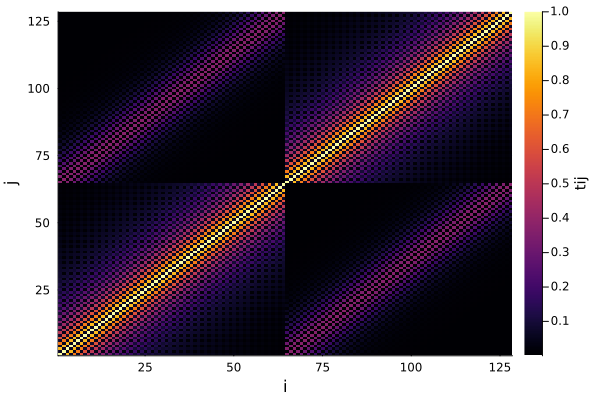

In [36]:
heatmap(1:Int(N/stepp), 1:Int(N/stepp), truevals, xlabel="i", ylabel="j", colorbar_title="tij")

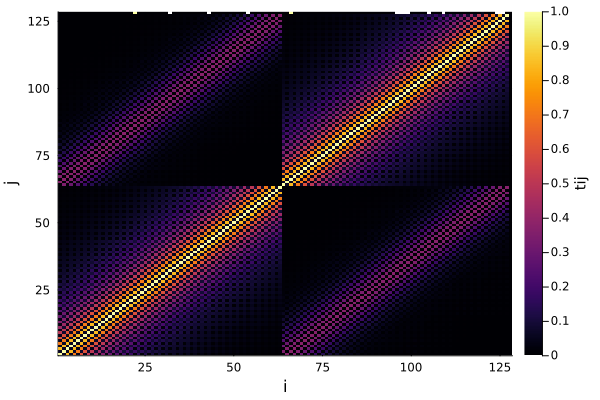

In [40]:
heatmap(1:Int(N/stepp), 1:Int(N/stepp), approxvals, xlabel="i", ylabel="j", colorbar_title="tij",clim = (0,1))